# Description

This notebook plots the statistics (mean, variance and SCV) of the delegation process, i.e., the packets that were redirected away from the VNF.

It assumes that the following simulation results are present:
- multiple values of $\theta$ for a single value of $k$ (e.g., $k = 0.5$ and $\theta \in \{5, 10, 15 \}$)

Requires `pandas, matplotlib, numpy, seaborn`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

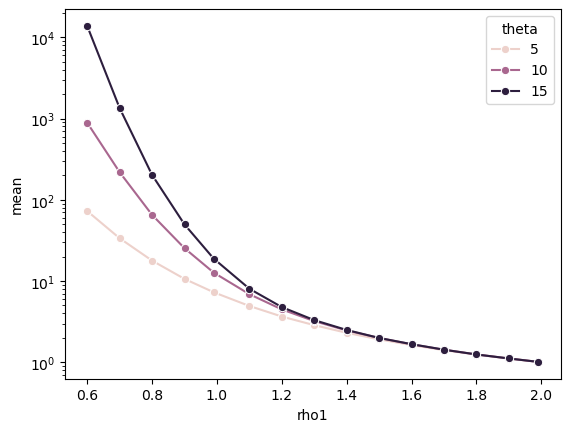

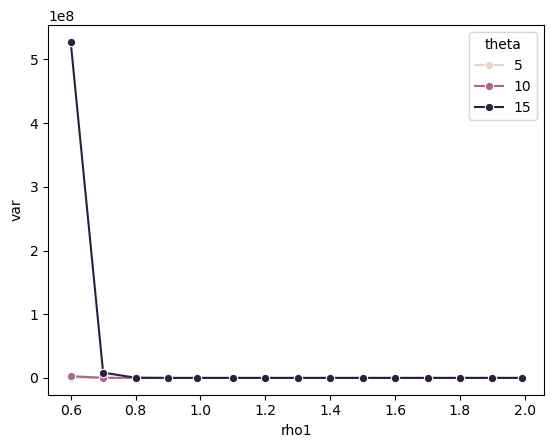

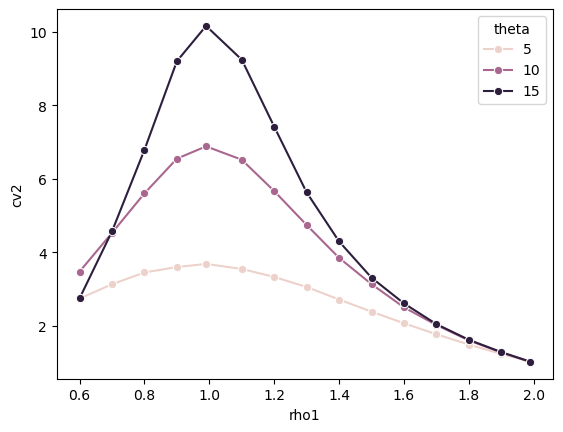

In [ ]:
K = 0.5
THETAS = [5, 10, 15]
all_deleg_stats = pd.DataFrame()
for THETA in THETAS
    df = pd.read_csv(f'../csv/k={K:.01f}_theta={THETA}/events.csv')
    param_df = pd.read_csv(f'../csv/k={K:.01f}_theta={THETA}/params.csv')
    N = param_df['N'].iloc[0]
    WARMUP = 50_000
    df = df[df['msg_id'] >= WARMUP]

    param_df['rho1'] = param_df['arr_rate'] / param_df['dep_rate']
    param_df['rho2'] = param_df['k'] * param_df['arr_rate'] / param_df['dep_rate']

    deleg_df = df[df['event'] == 'delegation'].copy()
    deleg_df['time_diff'] = deleg_df.groupby('id')['time'].diff()
    deleg_df.dropna(inplace=True)

    deleg_stats = deleg_df.groupby('id')['time_diff'].aggregate(['mean', 'var']).reset_index()
    deleg_stats['cv2'] = deleg_stats['var'] / (deleg_stats['mean'] ** 2)
    deleg_stats = deleg_stats.merge(param_df, on='id')
    all_deleg_stats = pd.concat([all_deleg_stats, deleg_stats])
sns.lineplot(data=all_deleg_stats, x='rho1', y='mean', marker='o', hue='theta')
plt.yscale('log')
plt.show()
sns.lineplot(data=all_deleg_stats, x='rho1', y='var', marker='o', hue='theta')
plt.show()
sns.lineplot(data=all_deleg_stats, x='rho1', y='cv2', marker='o', hue='theta')
plt.show()